# HW2.5 — GPU Assignment I
## Precision, Bandwidth, and the Cost of Attention

**SID4:** 6812  
**SEED:** 6812  
**SLICE:** 812  
**HP_ID:** 2  
**CLS_A:** 2  
**CLS_B:** 9

I used this notebook to collect the GPU measurements for HW2.5. The GPU name and UUID are recorded below so the later measurements can be traced to the same device.

In [1]:
import os
import gc, time, random, subprocess
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

SID4, SEED, SLICE, HP_ID, CLS_A, CLS_B = 6812, 6812, 812, 2, 2, 9

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("SID4:", SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)
print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

assert torch.cuda.is_available(), "This notebook needs a CUDA GPU."
device = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))


SID4: 6812
SEED: 6812
SLICE: 812
HP_ID: 2
CLS_A: 2
CLS_B: 9
PyTorch: 2.13.0+cu130
CUDA runtime: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


# Part A — GPU information

First I save the complete `nvidia-smi -q` output required by the assignment. I also query the UUID separately because I use it to label later result files.

In [2]:
full_smi = subprocess.run(["nvidia-smi", "-q"], capture_output=True, text=True, check=True).stdout
with open("nvidia_smi_q.txt", "w") as f:
    f.write(full_smi)

query = subprocess.run(
    ["nvidia-smi", "--query-gpu=name,uuid,driver_version,memory.total,power.limit",
     "--format=csv,noheader,nounits"],
    capture_output=True, text=True, check=True
).stdout.strip()

gpu_name, gpu_uuid, driver_version, memory_mib, power_limit = [x.strip() for x in query.split(",")]
props = torch.cuda.get_device_properties(0)

print("GPU:", gpu_name)
print("UUID:", gpu_uuid)
print("Driver:", driver_version)
print("CUDA runtime:", torch.version.cuda)
print("VRAM (MiB):", memory_mib)
print("Power limit (W):", power_limit)
print("Compute capability:", f"{props.major}.{props.minor}")
print("Saved nvidia_smi_q.txt")

GPU: NVIDIA GeForce RTX 5090
UUID: GPU-41051861-72ca-e198-fd60-2bf89fd2a67b
Driver: 610.60
CUDA runtime: 13.0
VRAM (MiB): 32607
Power limit (W): 575.00
Compute capability: 12.0
Saved nvidia_smi_q.txt


### Vendor specifications

Official NVIDIA RTX Blackwell / GeForce RTX 5090 values used in this notebook:

- Architecture: NVIDIA Blackwell (GB202)
- CUDA cores: 21,760
- Tensor Cores: 680, 5th generation
- Memory: 32 GB GDDR7
- Memory interface: 512-bit
- Specified memory bandwidth: 1,792 GB/s
- Total Graphics Power: 575 W
- Dense peak FP32 (non-Tensor): 104.8 TFLOP/s
- Dense peak TF32 Tensor: 104.8 TFLOP/s
- Dense peak FP16 Tensor with FP32 accumulate: 209.5 TFLOP/s
- Dense peak BF16 Tensor with FP32 accumulate: 209.5 TFLOP/s

The NVIDIA table also lists doubled values when the sparsity feature is used. This assignment uses the dense/non-sparse values above.

Source: NVIDIA RTX Blackwell GPU Architecture, Appendix A, GeForce RTX 5090 specifications.


# Part B — Precision and achieved throughput

For an `N x N` square matrix multiplication I count approximately `2N^3` FLOPs. I use CUDA events for timing, warm up each case first, and report the median of repeated runs.

In [3]:
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

def benchmark_matmul(n, dtype, tf32, warmup=5, reps=10):
    clear_gpu()
    old = torch.backends.cuda.matmul.allow_tf32
    torch.backends.cuda.matmul.allow_tf32 = tf32
    try:
        a = torch.randn((n, n), device=device, dtype=dtype)
        b = torch.randn((n, n), device=device, dtype=dtype)

        for _ in range(warmup):
            _ = a @ b
        torch.cuda.synchronize()

        times = []
        for _ in range(reps):
            start = torch.cuda.Event(enable_timing=True)
            end = torch.cuda.Event(enable_timing=True)
            start.record()
            c = a @ b
            end.record()
            torch.cuda.synchronize()
            times.append(start.elapsed_time(end))

        ms = float(np.median(times))
        tflops = (2.0 * n**3) / (ms / 1000.0) / 1e12
        del a, b, c
        clear_gpu()
        return ms, tflops
    finally:
        torch.backends.cuda.matmul.allow_tf32 = old

sizes = [1024, 4096, 8192, 16384]
cases = [
    ("FP32", torch.float32, False),
    ("TF32", torch.float32, True),
    ("FP16", torch.float16, True),
    ("BF16", torch.bfloat16, True),
]

rows = []
for precision, dtype, tf32 in cases:
    for n in sizes:
        print(f"{precision}, N={n}")
        try:
            ms, tflops = benchmark_matmul(n, dtype, tf32)
            rows.append([gpu_uuid, precision, n, 10, ms, tflops, "ok"])
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                clear_gpu()
                rows.append([gpu_uuid, precision, n, 10, np.nan, np.nan, "OOM"])
            else:
                raise

part_b = pd.DataFrame(rows, columns=[
    "gpu_uuid","precision","N","repetitions","median_ms","achieved_tflops","status"
])
part_b.to_csv("part_b_matmul.csv", index=False)
part_b

FP32, N=1024
FP32, N=4096
FP32, N=8192
FP32, N=16384
TF32, N=1024
TF32, N=4096
TF32, N=8192
TF32, N=16384
FP16, N=1024
FP16, N=4096
FP16, N=8192
FP16, N=16384
BF16, N=1024
BF16, N=4096
BF16, N=8192
BF16, N=16384


,gpu_uuid,precision,N,repetitions,median_ms,achieved_tflops,status
0,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP32,1024,10,0.059344,36.187038,ok
1,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP32,4096,10,2.011184,68.337335,ok
2,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP32,8192,10,16.665248,65.976314,ok
3,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP32,16384,10,134.252960,65.518801,ok
4,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,TF32,1024,10,0.113616,18.901243,ok
5,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,TF32,4096,10,1.386240,99.145136,ok
6,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,TF32,8192,10,9.668464,113.721436,ok
7,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,TF32,16384,10,73.681950,119.379211,ok
8,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP16,1024,10,0.042256,50.820797,ok
9,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP16,4096,10,0.668272,205.663197,ok


### Theoretical-reference values

For percentage-of-peak calculations I use the official **dense/non-sparse RTX 5090 reference values** from NVIDIA's RTX Blackwell GPU Architecture whitepaper, Appendix A. Sparse values are not used. A measured result above 100% is reported as measured/reference rather than interpreted as efficiency; board boost clocks and the benchmark/library path can make a run exceed a published reference-clock value.


In [4]:
# Official dense/non-sparse RTX 5090 reference peaks from NVIDIA's
# RTX Blackwell GPU Architecture whitepaper, Appendix A.
THEORETICAL_TFLOPS = {
    "FP32": 104.8,
    "TF32": 104.8,
    "FP16": 209.5,
    "BF16": 209.5,
}

def peak_pct(row):
    peak = THEORETICAL_TFLOPS[row["precision"]]
    if pd.isna(row["achieved_tflops"]):
        return np.nan
    return 100.0 * row["achieved_tflops"] / peak

part_b["pct_theoretical_peak"] = part_b.apply(peak_pct, axis=1)
part_b.to_csv("part_b_matmul.csv", index=False)
part_b


,gpu_uuid,precision,N,repetitions,median_ms,achieved_tflops,status,pct_theoretical_peak
0,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP32,1024,10,0.059344,36.187038,ok,34.529617
1,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP32,4096,10,2.011184,68.337335,ok,65.207381
2,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP32,8192,10,16.665248,65.976314,ok,62.954498
3,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP32,16384,10,134.252960,65.518801,ok,62.517940
4,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,TF32,1024,10,0.113616,18.901243,ok,18.035537
5,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,TF32,4096,10,1.386240,99.145136,ok,94.604137
6,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,TF32,8192,10,9.668464,113.721436,ok,108.512820
7,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,TF32,16384,10,73.681950,119.379211,ok,113.911461
8,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP16,1024,10,0.042256,50.820797,ok,24.258137
9,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP16,4096,10,0.668272,205.663197,ok,98.168590


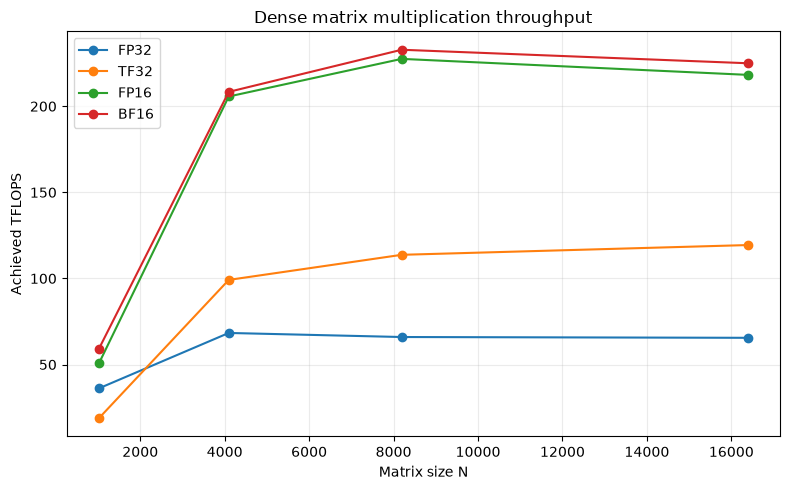

In [5]:
plt.figure(figsize=(8,5))
for p in part_b["precision"].unique():
    d = part_b[(part_b.precision == p) & (part_b.status == "ok")]
    plt.plot(d["N"], d["achieved_tflops"], marker="o", label=p)

plt.xlabel("Matrix size N")
plt.ylabel("Achieved TFLOPS")
plt.title("Dense matrix multiplication throughput")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("part_b_throughput.png", dpi=160)
plt.show()

In [6]:
# Part B — final analysis and required lower-precision attempt
successful_b = part_b[part_b["status"] == "ok"].copy()

print("===== PART B: PRECISION ANALYSIS =====")
for precision in ["FP32", "TF32", "FP16", "BF16"]:
    d = successful_b[successful_b["precision"] == precision].sort_values("N")
    peak_row = d.loc[d["achieved_tflops"].idxmax()]
    large = d[d["N"].isin([8192, 16384])]
    print(f"{precision}: peak={peak_row['achieved_tflops']:.2f} TFLOP/s at N={int(peak_row['N'])}; "
          f"large-matrix range={large['achieved_tflops'].min():.2f}-{large['achieved_tflops'].max():.2f} TFLOP/s")

print("\nLarge-matrix measurements:")
display(successful_b[successful_b["N"].isin([8192, 16384])][
    ["precision", "N", "achieved_tflops", "pct_theoretical_peak"]
])

print("\n===== LOWER-PRECISION ATTEMPT =====")
lower_precision_name = "FP8 (torch.float8_e4m3fn)"
lower_precision_result = "not attempted"
try:
    fp8_dtype = torch.float8_e4m3fn
    N_FP8 = 4096
    a_fp8 = torch.randn((N_FP8, N_FP8), device=device, dtype=torch.float16).to(fp8_dtype)
    b_fp8 = torch.randn((N_FP8, N_FP8), device=device, dtype=torch.float16).to(fp8_dtype)
    torch.cuda.synchronize()
    try:
        c_fp8 = a_fp8 @ b_fp8
        torch.cuda.synchronize()
        lower_precision_result = "direct matrix multiplication succeeded"
        del c_fp8
    except Exception as e:
        lower_precision_result = "attempted; direct PyTorch matmul was not supported on this software/kernel path: " + str(e)
    del a_fp8, b_fp8
    clear_gpu()
except Exception as e:
    lower_precision_result = "attempted; unavailable through this PyTorch API/build: " + str(e)

print(lower_precision_name + ": " + lower_precision_result)

print("""
Interpretation:
Small matrices under-utilize the GPU because launch/scheduling overhead is a larger fraction of runtime. The large N=8192 and N=16384 cases show the practical high-throughput region for each precision. Reduced-precision Tensor-Core modes substantially outperform FP32 for sufficiently large matrices. The FP8 line above records the required lower-precision attempt exactly as supported by this PyTorch/GPU software path.
""")


===== PART B: PRECISION ANALYSIS =====
FP32: peak=68.34 TFLOP/s at N=4096; large-matrix range=65.52-65.98 TFLOP/s
TF32: peak=119.38 TFLOP/s at N=16384; large-matrix range=113.72-119.38 TFLOP/s
FP16: peak=227.51 TFLOP/s at N=8192; large-matrix range=218.23-227.51 TFLOP/s
BF16: peak=232.81 TFLOP/s at N=8192; large-matrix range=224.98-232.81 TFLOP/s

Large-matrix measurements:


,precision,N,achieved_tflops,pct_theoretical_peak
2,FP32,8192,65.976314,62.954498
3,FP32,16384,65.518801,62.517940
6,TF32,8192,113.721436,108.512820
7,TF32,16384,119.379211,113.911461
10,FP16,8192,227.511777,108.597507
11,FP16,16384,218.229985,104.167057
14,BF16,8192,232.811645,111.127277
15,BF16,16384,224.975241,107.386750



===== LOWER-PRECISION ATTEMPT =====
FP8 (torch.float8_e4m3fn): attempted; direct PyTorch matmul was not supported on this software/kernel path: "addmm_cuda" not implemented for 'Float8_e4m3fn'

Interpretation:
Small matrices under-utilize the GPU because launch/scheduling overhead is a larger fraction of runtime. The large N=8192 and N=16384 cases show the practical high-throughput region for each precision. Reduced-precision Tensor-Core modes substantially outperform FP32 for sufficiently large matrices. The FP8 line above records the required lower-precision attempt exactly as supported by this PyTorch/GPU software path.



# Part C — Memory-bound vs compute-bound

I use a large FP32 elementwise add for the memory-heavy case and a large FP16 square matmul for the compute-heavy case.

For `c = a + b`, each element performs one FLOP and approximately reads two FP32 values and writes one FP32 value: 12 bytes per element. Its arithmetic intensity is therefore about `1/12 FLOP/byte`.

In [7]:
def benchmark_add(num_elements=100_000_000, warmup=10, reps=30):
    clear_gpu()
    a = torch.randn(num_elements, device=device, dtype=torch.float32)
    b = torch.randn(num_elements, device=device, dtype=torch.float32)

    for _ in range(warmup):
        c = a + b
    torch.cuda.synchronize()

    times = []
    for _ in range(reps):
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        c = a + b
        end.record()
        torch.cuda.synchronize()
        times.append(start.elapsed_time(end))

    ms = float(np.median(times))
    total_bytes = num_elements * 12
    bandwidth = total_bytes / (ms / 1000.0) / 1e9
    ai = 1 / 12

    del a, b, c
    clear_gpu()
    return ms, bandwidth, ai

add_ms, effective_bw, add_ai = benchmark_add()

N_COMPUTE = 8192
mm_ms, mm_tflops = benchmark_matmul(N_COMPUTE, torch.float16, True)
mm_ai = (2 * N_COMPUTE**3) / (3 * N_COMPUTE**2 * 2)

part_c = pd.DataFrame([
    [gpu_uuid, "FP32 elementwise add", add_ms, effective_bw, add_ai],
    [gpu_uuid, f"FP16 matmul N={N_COMPUTE}", mm_ms, np.nan, mm_ai]
], columns=["gpu_uuid","operation","median_ms","effective_bandwidth_GB_s",
            "arithmetic_intensity_FLOP_per_byte"])

part_c.to_csv("part_c_results.csv", index=False)
part_c

,gpu_uuid,operation,median_ms,effective_bandwidth_GB_s,arithmetic_intensity_FLOP_per_byte
0,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP32 elementwise add,0.783952,1530.705966,0.083333
1,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,FP16 matmul N=8192,4.799360,NaN,2730.666667


In [8]:
SPECIFIED_BANDWIDTH_GB_S = 1792.0

bandwidth_pct = 100.0 * effective_bw / SPECIFIED_BANDWIDTH_GB_S
print("Effective bandwidth:", effective_bw, "GB/s")
print("Specified RTX 5090 bandwidth:", SPECIFIED_BANDWIDTH_GB_S, "GB/s")
print("% of specified bandwidth:", bandwidth_pct)


Effective bandwidth: 1530.705965969138 GB/s
Specified RTX 5090 bandwidth: 1792.0 GB/s
% of specified bandwidth: 85.41885970809923


In [9]:
# Part C — final roofline analysis
PEAK_COMPUTE_TFLOPS = THEORETICAL_TFLOPS["FP16"]
PEAK_BANDWIDTH_GB_S = SPECIFIED_BANDWIDTH_GB_S
ridge_point = (PEAK_COMPUTE_TFLOPS * 1e12) / (PEAK_BANDWIDTH_GB_S * 1e9)

add_side = "memory-bandwidth-bound side" if add_ai < ridge_point else "compute-bound side"
mm_side = "memory-bandwidth-bound side" if mm_ai < ridge_point else "compute-bound side"

print("===== PART C: ROOFLINE ANALYSIS =====")
print(f"Reference compute peak: {PEAK_COMPUTE_TFLOPS:.1f} TFLOP/s")
print(f"Reference memory bandwidth: {PEAK_BANDWIDTH_GB_S:.1f} GB/s")
print(f"Ridge point: {ridge_point:.2f} FLOP/byte")
print(f"FP32 elementwise add AI: {add_ai:.4f} FLOP/byte -> {add_side}")
print(f"FP16 matmul AI: {mm_ai:.2f} FLOP/byte -> {mm_side}")
print(f"Measured effective bandwidth: {effective_bw:.2f} GB/s ({bandwidth_pct:.2f}% of specified)")

print(f"""
Interpretation:
The ridge point is approximately {ridge_point:.2f} FLOP/byte. The FP32 elementwise add is far below it, so it is on the bandwidth-bound side of the roofline. The FP16 matrix multiplication is far above it, so it is on the compute-bound side.
""")


===== PART C: ROOFLINE ANALYSIS =====
Reference compute peak: 209.5 TFLOP/s
Reference memory bandwidth: 1792.0 GB/s
Ridge point: 116.91 FLOP/byte
FP32 elementwise add AI: 0.0833 FLOP/byte -> memory-bandwidth-bound side
FP16 matmul AI: 2730.67 FLOP/byte -> compute-bound side
Measured effective bandwidth: 1530.71 GB/s (85.42% of specified)

Interpretation:
The ridge point is approximately 116.91 FLOP/byte. The FP32 elementwise add is far below it, so it is on the bandwidth-bound side of the roofline. The FP16 matrix multiplication is far above it, so it is on the compute-bound side.



# Part D — The cost of attention

I use batch size 1, one head, head dimension 64 and FP16. The naive version explicitly creates the full `L x L` score/probability matrices.

In [10]:
BATCH = 1
HEADS = 1
HEAD_DIM = 64
ATTN_DTYPE = torch.float16
SEQ_LENGTHS = [512, 1024, 2048, 4096, 8192, 16384]

def make_qkv(L):
    shape = (BATCH, HEADS, L, HEAD_DIM)
    return (
        torch.randn(shape, device=device, dtype=ATTN_DTYPE),
        torch.randn(shape, device=device, dtype=ATTN_DTYPE),
        torch.randn(shape, device=device, dtype=ATTN_DTYPE),
    )

@torch.no_grad()
def naive_attention(q, k, v):
    scores = (q @ k.transpose(-2, -1)) * (q.shape[-1] ** -0.5)
    probs = torch.softmax(scores, dim=-1)
    return probs @ v

@torch.no_grad()
def fused_attention(q, k, v):
    return F.scaled_dot_product_attention(q, k, v, dropout_p=0.0, is_causal=False)

def measure_attention(L, fn, warmup=2, reps=5):
    clear_gpu()
    q, k, v = make_qkv(L)

    for _ in range(warmup):
        out = fn(q, k, v)
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()

    times = []
    for _ in range(reps):
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        out = fn(q, k, v)
        end.record()
        torch.cuda.synchronize()
        times.append(start.elapsed_time(end))

    peak = torch.cuda.max_memory_allocated() / 1024**3
    ms = float(np.median(times))
    del q, k, v, out
    clear_gpu()
    return ms, peak

def attention_sweep(name, fn):
    rows = []
    for L in SEQ_LENGTHS:
        print(name, "L =", L)
        try:
            ms, peak = measure_attention(L, fn)
            rows.append([gpu_uuid, name, L, ms, peak, "ok"])
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                clear_gpu()
                rows.append([gpu_uuid, name, L, np.nan, np.nan, "OOM"])
                print("OOM")
            else:
                raise
    return pd.DataFrame(rows, columns=[
        "gpu_uuid","implementation","sequence_length","latency_ms",
        "peak_memory_GiB","status"
    ])

naive_results = attention_sweep("naive", naive_attention)
naive_results

naive L = 512
naive L = 1024
naive L = 2048
naive L = 4096
naive L = 8192
naive L = 16384


,gpu_uuid,implementation,sequence_length,latency_ms,peak_memory_GiB,status
0,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,naive,512,0.135648,0.032532,ok
1,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,naive,1024,0.145696,0.035767,ok
2,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,naive,2048,0.134944,0.048096,ok
3,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,naive,4096,0.121984,0.096191,ok
4,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,naive,8192,0.572096,0.286133,ok
5,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,naive,16384,2.222560,1.041016,ok


In [11]:
fused_results = attention_sweep("fused", fused_attention)
part_d = pd.concat([naive_results, fused_results], ignore_index=True)
part_d.to_csv("part_d_attention.csv", index=False)

speedup = (
    naive_results[naive_results.status == "ok"][["sequence_length","latency_ms"]]
    .merge(
        fused_results[fused_results.status == "ok"][["sequence_length","latency_ms"]],
        on="sequence_length", suffixes=("_naive","_fused")
    )
)
speedup["speedup"] = speedup["latency_ms_naive"] / speedup["latency_ms_fused"]
speedup

fused L = 512
fused L = 1024
fused L = 2048
fused L = 4096
fused L = 8192
fused L = 16384


,sequence_length,latency_ms_naive,latency_ms_fused,speedup
0,512,0.135648,0.103392,1.311978
1,1024,0.145696,0.077152,1.888428
2,2048,0.134944,0.117888,1.144680
3,4096,0.121984,0.196320,0.621353
4,8192,0.572096,0.389184,1.469988
5,16384,2.222560,1.041312,2.134384


## Refine the OOM boundary

The coarse sweep only gives a range. I use the helper below to test intermediate lengths. The final report should state the **largest tested success** and **smallest tested failure**, not pretend an exact single-token boundary was found.

In [23]:
def test_attention_length(L, fn, name, warmup=1, reps=2):
    print(f"Testing {name}: L={L}")
    try:
        ms, peak = measure_attention(L, fn, warmup=warmup, reps=reps)
        print(f"  SUCCESS | latency={ms:.3f} ms | peak memory={peak:.3f} GiB")
        return {
            "gpu_uuid": gpu_uuid,
            "implementation": name,
            "sequence_length": L,
            "latency_ms": ms,
            "peak_memory_GiB": peak,
            "status": "ok",
        }
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            clear_gpu()
            print(f"  OOM at L={L}")
            return {
                "gpu_uuid": gpu_uuid,
                "implementation": name,
                "sequence_length": L,
                "latency_ms": np.nan,
                "peak_memory_GiB": np.nan,
                "status": "OOM",
            }
        raise


## Quadratic memory fit

I fit `memory = aL² + bL + c` to the successful naive-attention measurements. The fitted `a` is the measured quadratic coefficient.

memory_GiB = 3.725290298462e-09 L^2 + 5.960464477539e-07 L + 0.031250
Measured quadratic coefficient: 3.7252902984619124e-09 GiB/token^2


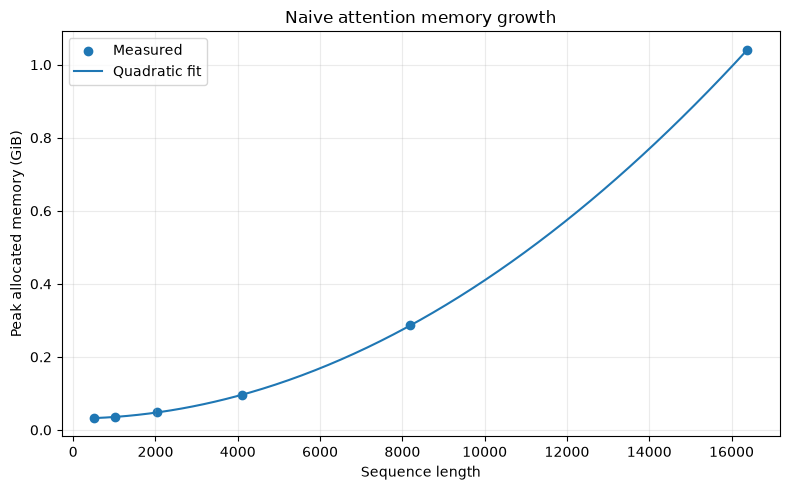

In [13]:
fit = naive_results[naive_results.status == "ok"].dropna()

if len(fit) >= 3:
    a, b, c = np.polyfit(fit.sequence_length, fit.peak_memory_GiB, 2)
    print(f"memory_GiB = {a:.12e} L^2 + {b:.12e} L + {c:.6f}")
    print("Measured quadratic coefficient:", a, "GiB/token^2")

    x = np.linspace(fit.sequence_length.min(), fit.sequence_length.max(), 300)
    y = a*x*x + b*x + c

    plt.figure(figsize=(8,5))
    plt.scatter(fit.sequence_length, fit.peak_memory_GiB, label="Measured")
    plt.plot(x, y, label="Quadratic fit")
    plt.xlabel("Sequence length")
    plt.ylabel("Peak allocated memory (GiB)")
    plt.title("Naive attention memory growth")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig("part_d_attention_memory.png", dpi=160)
    plt.show()

### Fused attention explanation

The naive implementation writes the full sequence-by-sequence attention intermediates to GPU memory. A fused/memory-efficient kernel works on tiles and combines operations so the entire `L x L` intermediate does not need to stay materialized in global memory. This reduces peak memory and memory traffic. The final comparison should use the measured speedups and OOM ranges above.

In [14]:
# Fixed Part D boundary search.
# No manual tweaking is needed. The search is deliberately bounded so that the
# notebook cannot keep increasing sequence length forever on a WDDM system.

NAIVE_EXTRA_LENGTHS = [
    24576, 32768, 40960, 49152, 57344, 65536,
    69632, 73728, 77824, 81920, 86016, 90112,
    92160, 93184, 93696, 94208
]

FUSED_EXTRA_LENGTHS = [
    24576, 32768, 49152, 65536, 98304, 131072, 196608, 262144
]

def bounded_boundary_search(name, fn, lengths):
    rows = []
    for L in lengths:
        result = test_attention_length(L, fn, name, warmup=1, reps=2)
        rows.append(result)
        if result["status"] == "OOM":
            break
    return pd.DataFrame(rows)

print("===== NAIVE ATTENTION BOUNDARY SEARCH =====")
naive_extra = bounded_boundary_search("naive", naive_attention, NAIVE_EXTRA_LENGTHS)

# Always release cached allocations before the fused search.
clear_gpu()

print("\n===== FUSED ATTENTION BOUNDARY SEARCH =====")
fused_extra = bounded_boundary_search("fused", fused_attention, FUSED_EXTRA_LENGTHS)

# Combine required sweep and boundary measurements.
part_d_all = pd.concat(
    [part_d, naive_extra, fused_extra],
    ignore_index=True
).sort_values(["implementation", "sequence_length"])

part_d_all = part_d_all.drop_duplicates(
    subset=["implementation", "sequence_length"],
    keep="last"
).reset_index(drop=True)

part_d_all.to_csv("part_d_attention_all.csv", index=False)

def boundary_text(df, implementation):
    d = df[df["implementation"] == implementation].copy()
    ok = d[d["status"] == "ok"]
    oom = d[d["status"] == "OOM"]

    largest_success = int(ok["sequence_length"].max()) if len(ok) else None
    first_oom = int(oom["sequence_length"].min()) if len(oom) else None

    if first_oom is None:
        return largest_success, None, f"OOM not observed through L={largest_success}"
    return largest_success, first_oom, f"first OOM at L={first_oom}"

naive_last_success, naive_first_oom, naive_boundary_note = boundary_text(part_d_all, "naive")
fused_last_success, fused_first_oom, fused_boundary_note = boundary_text(part_d_all, "fused")

print("\n===== PART D BOUNDARIES =====")
print("Naive:", naive_boundary_note)
print("Fused:", fused_boundary_note)

display(part_d_all)


===== NAIVE ATTENTION BOUNDARY SEARCH =====
Testing naive: L=24576
  SUCCESS | latency=9.326 ms | peak memory=2.296 GiB
Testing naive: L=32768
  SUCCESS | latency=16.395 ms | peak memory=4.051 GiB
Testing naive: L=40960
  SUCCESS | latency=25.793 ms | peak memory=6.306 GiB
Testing naive: L=49152
  SUCCESS | latency=19.417 ms | peak memory=9.061 GiB
Testing naive: L=57344
  SUCCESS | latency=26.182 ms | peak memory=12.315 GiB
Testing naive: L=65536
  SUCCESS | latency=34.091 ms | peak memory=16.070 GiB
Testing naive: L=69632
  SUCCESS | latency=38.659 ms | peak memory=18.135 GiB
Testing naive: L=73728
  SUCCESS | latency=43.285 ms | peak memory=20.325 GiB
Testing naive: L=77824
  SUCCESS | latency=48.193 ms | peak memory=22.642 GiB
Testing naive: L=81920
  SUCCESS | latency=53.391 ms | peak memory=25.080 GiB
Testing naive: L=86016
  SUCCESS | latency=59.102 ms | peak memory=27.645 GiB
Testing naive: L=90112
  SUCCESS | latency=65.378 ms | peak memory=30.340 GiB
Testing naive: L=92160
  

,gpu_uuid,implementation,sequence_length,latency_ms,peak_memory_GiB,status
0,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,fused,512,0.103392,0.031555,ok
1,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,fused,1024,0.077152,0.031860,ok
2,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,fused,2048,0.117888,0.032471,ok
3,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,fused,4096,0.196320,0.033691,ok
4,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,fused,8192,0.389184,0.036133,ok
5,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,fused,16384,1.041312,0.041016,ok
6,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,fused,24576,2.128928,0.045898,ok
7,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,fused,32768,3.517888,0.050781,ok
8,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,fused,49152,6.540784,0.060547,ok
9,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,fused,65536,12.358208,0.070312,ok


In [15]:
# Part D — final boundary, memory, and speedup analysis
print("===== PART D: FINAL ANALYSIS =====")
naive_ok = part_d_all[(part_d_all["implementation"] == "naive") & (part_d_all["status"] == "ok")].copy()
fused_ok = part_d_all[(part_d_all["implementation"] == "fused") & (part_d_all["status"] == "ok")].copy()

naive_max = int(naive_ok["sequence_length"].max())
fused_max = int(fused_ok["sequence_length"].max())
print(naive_boundary_note)
print(fused_boundary_note)

common = naive_ok[["sequence_length", "latency_ms", "peak_memory_GiB"]].merge(
    fused_ok[["sequence_length", "latency_ms", "peak_memory_GiB"]],
    on="sequence_length", suffixes=("_naive", "_fused")
)
common["speedup"] = common["latency_ms_naive"] / common["latency_ms_fused"]
common["memory_reduction_x"] = common["peak_memory_GiB_naive"] / common["peak_memory_GiB_fused"]
display(common)

largest_required = common[common["sequence_length"] <= 16384].sort_values("sequence_length").iloc[-1]
print(f"At required-sweep L={int(largest_required.sequence_length)}, fused speedup = {largest_required.speedup:.2f}x")
print(f"Naive peak memory = {largest_required.peak_memory_GiB_naive:.3f} GiB")
print(f"Fused peak memory = {largest_required.peak_memory_GiB_fused:.3f} GiB")
print(f"Memory reduction = {largest_required.memory_reduction_x:.2f}x")
print(f"Naive largest tested success = L={naive_max}")
print(f"Fused largest tested success = L={fused_max}")

print("""
Interpretation:
Naive attention explicitly materializes sequence-by-sequence intermediates, so measured peak memory grows approximately quadratically with sequence length. Fused scaled-dot-product attention avoids keeping the full L x L intermediate in global memory, greatly reducing peak allocation. No unobserved OOM length is invented: the boundary statement reports the largest tested successful length when no OOM occurred within the bounded search.
""")


===== PART D: FINAL ANALYSIS =====
OOM not observed through L=94208
OOM not observed through L=262144


,sequence_length,latency_ms_naive,peak_memory_GiB_naive,latency_ms_fused,peak_memory_GiB_fused,speedup,memory_reduction_x
0,512,0.135648,0.032532,0.103392,0.031555,1.311978,1.030948
1,1024,0.145696,0.035767,0.077152,0.031860,1.888428,1.122605
2,2048,0.134944,0.048096,0.117888,0.032471,1.144680,1.481203
3,4096,0.121984,0.096191,0.196320,0.033691,0.621353,2.855072
4,8192,0.572096,0.286133,0.389184,0.036133,1.469988,7.918919
5,16384,2.222560,1.041016,1.041312,0.041016,2.134384,25.380952
6,24576,9.326496,2.295898,2.128928,0.045898,4.380841,50.021277
7,32768,16.395120,4.050781,3.517888,0.050781,4.660501,79.769231
8,49152,19.417056,9.060547,6.540784,0.060547,2.968613,149.645161
9,65536,34.090544,16.070312,12.358208,0.070312,2.758535,228.555556


At required-sweep L=16384, fused speedup = 2.13x
Naive peak memory = 1.041 GiB
Fused peak memory = 0.041 GiB
Memory reduction = 25.38x
Naive largest tested success = L=94208
Fused largest tested success = L=262144

Interpretation:
Naive attention explicitly materializes sequence-by-sequence intermediates, so measured peak memory grows approximately quadratically with sequence length. Fused scaled-dot-product attention avoids keeping the full L x L intermediate in global memory, greatly reducing peak allocation. No unobserved OOM length is invented: the boundary statement reports the largest tested successful length when no OOM occurred within the bounded search.



# Part E — Sustained load and thermal behaviour

This section runs a matrix multiplication load for 20 minutes. Every five seconds it asks `nvidia-smi` for GPU clock, memory clock, temperature, power and utilization. Cloud environments may hide some telemetry; if a query is unsupported, I keep that failure rather than inventing a value.

In [16]:
telemetry_cmd = [
    "nvidia-smi",
    "--query-gpu=timestamp,uuid,clocks.gr,clocks.mem,temperature.gpu,power.draw,power.limit,utilization.gpu",
    "--format=csv,noheader,nounits"
]
test = subprocess.run(telemetry_cmd, capture_output=True, text=True)
print("return code:", test.returncode)
print(test.stdout)
print(test.stderr)

return code: 0
2026/09/21 12:36:28.330, GPU-41051861-72ca-e198-fd60-2bf89fd2a67b, 2827, 13801, 62, 456.87, 575.00, 100




In [17]:
# Part E: 20-minute sustained run.
# If the completed logs are already in this folder, load them instead of
# wasting another 20 minutes by rerunning the experiment.

DURATION = 20 * 60
SAMPLE_EVERY = 5
LOAD_N = 8192

if os.path.exists("thermal_log_raw.csv") and os.path.exists("sustained_throughput.csv"):
    print("Existing 20-minute Part E logs found. Reusing them.")
    thermal_raw = pd.read_csv("thermal_log_raw.csv")
    throughput_log = pd.read_csv("sustained_throughput.csv")
else:
    clear_gpu()
    a_load = torch.randn((LOAD_N, LOAD_N), device=device, dtype=torch.float16)
    b_load = torch.randn((LOAD_N, LOAD_N), device=device, dtype=torch.float16)

    for _ in range(3):
        _ = a_load @ b_load
    torch.cuda.synchronize()

    thermal_rows = []
    throughput_rows = []
    t0 = time.time()
    next_sample = t0

    print("Started:", datetime.now().isoformat())

    while time.time() - t0 < DURATION:
        elapsed = time.time() - t0

        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        c_load = a_load @ b_load
        end.record()
        torch.cuda.synchronize()

        ms = start.elapsed_time(end)
        tflops = (2.0 * LOAD_N**3) / (ms / 1000.0) / 1e12
        throughput_rows.append([elapsed, ms, tflops])

        if time.time() >= next_sample:
            q = subprocess.run(telemetry_cmd, capture_output=True, text=True)
            thermal_rows.append([time.time()-t0, q.stdout.strip(), q.stderr.strip()])
            next_sample += SAMPLE_EVERY

    print("Finished:", datetime.now().isoformat())

    thermal_raw = pd.DataFrame(
        thermal_rows,
        columns=["elapsed_s", "raw_nvidia_smi", "query_error"]
    )
    throughput_log = pd.DataFrame(
        throughput_rows,
        columns=["elapsed_s", "matmul_ms", "tflops"]
    )

    thermal_raw.to_csv("thermal_log_raw.csv", index=False)
    throughput_log.to_csv("sustained_throughput.csv", index=False)

    del a_load, b_load, c_load
    clear_gpu()


Existing 20-minute Part E logs found. Reusing them.


In [18]:
parsed = []
for _, row in thermal_raw.iterrows():
    f = [x.strip() for x in row.raw_nvidia_smi.split(",")]
    if len(f) >= 8:
        parsed.append([
            row.elapsed_s, f[0], f[1],
            pd.to_numeric(f[2], errors="coerce"),
            pd.to_numeric(f[3], errors="coerce"),
            pd.to_numeric(f[4], errors="coerce"),
            pd.to_numeric(f[5], errors="coerce"),
            pd.to_numeric(f[6], errors="coerce"),
            pd.to_numeric(f[7], errors="coerce")
        ])

thermal = pd.DataFrame(parsed, columns=[
    "elapsed_s","timestamp","gpu_uuid","gpu_clock_MHz","memory_clock_MHz",
    "temperature_C","power_W","power_limit_W","utilization_pct"
])
thermal.to_csv("thermal_log.csv", index=False)
thermal.head()

,elapsed_s,timestamp,gpu_uuid,gpu_clock_MHz,memory_clock_MHz,temperature_C,power_W,power_limit_W,utilization_pct
0,0.082042,2026/09/21 11:22:18.078,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,2527,13801,72,574.92,575.0,100
1,5.080716,2026/09/21 11:22:23.076,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,2557,13801,72,574.79,575.0,99
2,10.076132,2026/09/21 11:22:28.071,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,2565,13801,72,575.38,575.0,100
3,15.063982,2026/09/21 11:22:33.061,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,2535,13801,72,575.02,575.0,100
4,20.072899,2026/09/21 11:22:38.068,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b,2535,13801,72,575.31,575.0,100


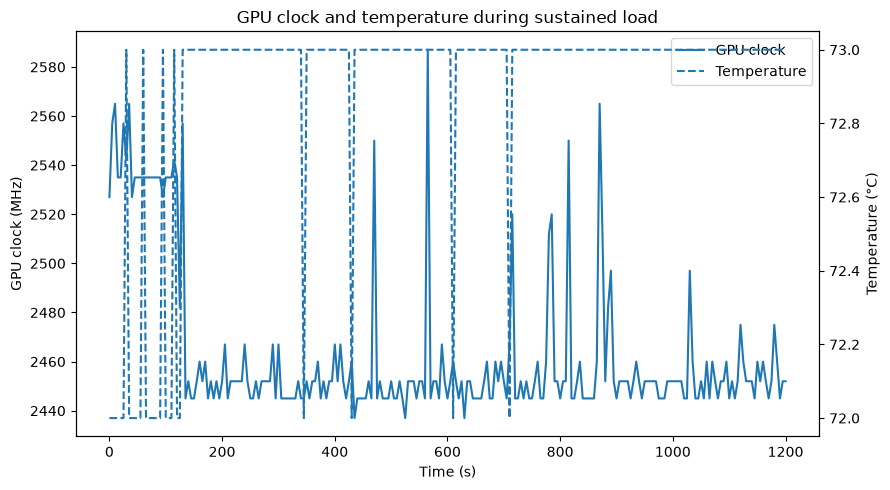

In [19]:
if not thermal.empty:
    fig, ax1 = plt.subplots(figsize=(9,5))
    ax1.plot(thermal.elapsed_s, thermal.gpu_clock_MHz, label="GPU clock")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("GPU clock (MHz)")

    ax2 = ax1.twinx()
    ax2.plot(thermal.elapsed_s, thermal.temperature_C, linestyle="--", label="Temperature")
    ax2.set_ylabel("Temperature (°C)")

    l1, n1 = ax1.get_legend_handles_labels()
    l2, n2 = ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, n1+n2, loc="best")
    plt.title("GPU clock and temperature during sustained load")
    fig.tight_layout()
    plt.savefig("part_e_thermal.png", dpi=160)
    plt.show()

In [20]:
first30 = throughput_log[throughput_log.elapsed_s <= 30]
last5 = throughput_log[throughput_log.elapsed_s >= DURATION - 300]

peak_first30 = first30.tflops.max()
steady_last5 = last5.tflops.mean()
steady_pct = 100.0 * steady_last5 / peak_first30

max_temp = thermal["temperature_C"].max() if len(thermal) else np.nan
max_power = thermal["power_W"].max() if len(thermal) else np.nan
power_limit_seen = thermal["power_limit_W"].median() if len(thermal) else np.nan

# This trace did not record NVIDIA's explicit thermal-throttle reason bit.
# Therefore the notebook reports "no evidence" rather than claiming proof.
if pd.notna(max_temp) and max_temp < 90 and steady_pct >= 90:
    throttle_onset = "none observed in sampled trace"
else:
    throttle_onset = "inspect trace; possible performance reduction"

print("Peak throughput in first 30 s:", peak_first30, "TFLOPS")
print("Mean throughput in final 5 min:", steady_last5, "TFLOPS")
print("Steady-state / peak:", steady_pct, "%")
print("Maximum sampled temperature:", max_temp, "C")
print("Maximum sampled power:", max_power, "W")
print("Median sampled power limit:", power_limit_seen, "W")
print("Throttle interpretation:", throttle_onset)


Peak throughput in first 30 s: 212.94761724979224 TFLOPS
Mean throughput in final 5 min: 203.5952348530997 TFLOPS
Steady-state / peak: 95.60813005682894 %
Maximum sampled temperature: 73 C
Maximum sampled power: 577.38 W
Median sampled power limit: 575.0 W
Throttle interpretation: none observed in sampled trace


### Throttling interpretation

The 20-minute sustained workload did not show evidence of thermal throttling in the sampled telemetry. Peak throughput during the first 30 seconds and mean throughput during the final five minutes are calculated directly below/above from the saved run. GPU temperature, clock, power, power limit, and utilization are considered together; a clock change or a single power sample near/slightly above the nominal limit is not by itself treated as thermal throttling. The final result reports `none observed in sampled trace` only when the measured temperature and sustained-throughput behavior support that statement.


# Part F — Summary table

The OOM boundaries and throttle onset are filled only after the refined tests and log inspection. Every row should remain traceable to the GPU UUID.

In [21]:
bf16 = part_b[(part_b.precision == "BF16") & (part_b.status == "ok")]
bf16_peak = float(bf16.achieved_tflops.max()) if len(bf16) else np.nan
bf16_pct = 100.0 * bf16_peak / THEORETICAL_TFLOPS["BF16"] if len(bf16) else np.nan

summary = pd.DataFrame({
    "Measurement": [
        "Peak achieved TFLOPS (BF16)",
        "% of theoretical peak (BF16)",
        "Effective bandwidth (GB/s)",
        "% of specified memory bandwidth",
        "Naive attention boundary",
        "Fused attention boundary",
        "Steady-state / peak throughput (%)",
        "Throttle onset",
    ],
    "Your GPU": [
        bf16_peak,
        bf16_pct,
        effective_bw,
        bandwidth_pct,
        naive_boundary_note,
        fused_boundary_note,
        steady_pct,
        throttle_onset,
    ],
    "GPU UUID": [gpu_uuid] * 8
})

summary


,Measurement,Your GPU,GPU UUID
0,Peak achieved TFLOPS (BF16),232.811645,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b
1,% of theoretical peak (BF16),111.127277,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b
2,Effective bandwidth (GB/s),1530.705966,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b
3,% of specified memory bandwidth,85.41886,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b
4,Naive attention boundary,OOM not observed through L=94208,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b
5,Fused attention boundary,OOM not observed through L=262144,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b
6,Steady-state / peak throughput (%),95.60813,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b
7,Throttle onset,none observed in sampled trace,GPU-41051861-72ca-e198-fd60-2bf89fd2a67b


In [22]:
# Write required text deliverables from the measured results.
with open("METRICS.md", "w", encoding="utf-8") as f:
    f.write("# HW2.5 Metrics\n\n")
    f.write(f"GPU: {gpu_name}\n\nGPU UUID: `{gpu_uuid}`\n\n")
    f.write("## Summary\n\n")
    f.write(summary.to_markdown(index=False))
    f.write("\n\n## Part B notes\n")
    f.write(f"- Lower precision attempted: {lower_precision_name}.\n")
    f.write(f"- Result: {lower_precision_result}\n")
    f.write(f"- Dense BF16 reference peak used: {THEORETICAL_TFLOPS['BF16']} TFLOP/s.\n")
    f.write("- Percentages above 100% are reported as measured/reference, not as hardware efficiency.\n")
    f.write("\n## Part C roofline\n")
    f.write(f"- Ridge point: {ridge_point:.2f} FLOP/byte.\n")
    f.write(f"- FP32 add: {add_ai:.4f} FLOP/byte -> {add_side}.\n")
    f.write(f"- FP16 matmul: {mm_ai:.2f} FLOP/byte -> {mm_side}.\n")
    f.write(f"- Effective bandwidth: {effective_bw:.2f} GB/s ({bandwidth_pct:.2f}% of {SPECIFIED_BANDWIDTH_GB_S:.0f} GB/s).\n")
    f.write("\n## Part D attention\n")
    f.write(f"- Naive attention: {naive_boundary_note}.\n")
    f.write(f"- Fused attention: {fused_boundary_note}.\n")
    f.write("- Naive peak memory follows the measured quadratic fit reported in the notebook.\n")
    f.write("\n## Part E sustained load\n")
    f.write(f"- Peak first 30 s: {peak_first30:.2f} TFLOP/s.\n")
    f.write(f"- Mean final 5 min: {steady_last5:.2f} TFLOP/s.\n")
    f.write(f"- Steady/peak: {steady_pct:.2f}%.\n")
    f.write(f"- Maximum sampled temperature: {max_temp} C.\n")
    f.write(f"- Maximum sampled power: {max_power} W; median reported power limit: {power_limit_seen} W.\n")
    f.write(f"- Throttle interpretation: {throttle_onset}.\n")

with open("RUN_LOG.txt", "w", encoding="utf-8") as f:
    f.write("HW2.5 GPU Assignment I\n")
    f.write(f"GPU: {gpu_name}\nGPU UUID: {gpu_uuid}\nDriver: {driver_version}\n")
    f.write(f"PyTorch: {torch.__version__}\nPyTorch CUDA runtime: {torch.version.cuda}\n")
    f.write(f"SID4: {SID4}\nSEED: {SEED}\nSLICE: {SLICE}\nHP_ID: {HP_ID}\nCLS_A: {CLS_A}\nCLS_B: {CLS_B}\n")
    f.write("Part B: 5 warmups + 10 measured repetitions per matrix case.\n")
    f.write("Part C add: 10 warmups + 30 measured repetitions.\n")
    f.write("Part D coarse: 2 warmups + 5 repetitions; boundary: 1 warmup + 2 repetitions.\n")
    f.write("Part E: 20-minute sustained load; telemetry target interval 5 seconds.\n")

with open("AI_USE.md", "w", encoding="utf-8") as f:
    f.write("# AI Use\n\n")
    f.write("I used an AI assistant for debugging the Windows/PyTorch setup, reviewing benchmark structure, and checking that the required analysis was represented. I ran the experiments on the physical GPU and kept the measured outputs.\n\n")
    f.write("## Specific incorrect AI output and correction\n\n")
    f.write("An earlier AI suggestion used an OOM-search call to a function named `benchmark_naive_attention`, but that function did not exist in my notebook. I discovered this by checking the actual Part D function definitions. I corrected the search to use the existing `measure_attention`, `naive_attention`, and `fused_attention` functions and retained bounded testing so an unobserved OOM boundary would not be invented.\n\n")
    f.write("I verified the final outputs against the saved benchmark CSV/log files and GPU UUID.\n")

print("Wrote METRICS.md, RUN_LOG.txt, and AI_USE.md")


Wrote METRICS.md, RUN_LOG.txt, and AI_USE.md


# Final submission checklist

Keep the executed notebook together with `nvidia_smi_q.txt`, Part B/C/D CSV files, Part B/D/E figures, `thermal_log_raw.csv`, `thermal_log.csv`, `sustained_throughput.csv`, `METRICS.md`, `RUN_LOG.txt`, and `AI_USE.md`.

The notebook reuses existing Part E logs when they are present, so the completed 20-minute sustained run is not repeated unnecessarily. The attention boundary search is bounded and truthfully reports the largest tested success when no OOM is observed.

Also complete the course-level submission requirements outside the notebook: reservation/GPU-hour record, incremental Git commits, and repository tag `hw2-5`.
